In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('./data/cleaned_fake_real_news.csv')
df.head(5)

,title,text,subject,date,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [28]:
df.shape

(44689, 5)

In [29]:
# Drop 'subject' and 'date' columns
df.drop(columns=['subject', 'date'], inplace=True)
df.head(5)

,title,text,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1


In [30]:
# trim any trailing spaces in the 'text' column
df['text'] = df['text'].str.strip()

# trim any trailing spaces in the 'title' column
df['title'] = df['title'].str.strip()

# merge the 'title' and 'text' columns into a new column called 'content'
df['content'] = df['title'] + ' ' + df['text']

In [31]:
# create a new dataframe with only the 'content' and 'target' columns
df_clean = df[['content', 'target']].copy()
# rename the 'target' column to 'label'
df_clean.rename(columns={'target': 'label'}, inplace=True)
# rename the 'content' column to 'news'
df_clean.rename(columns={'content': 'news'}, inplace=True)

# check the first 5 rows of the new dataframe
df_clean.head(5)

,news,label
0,Donald Trump Sends Out Embarrassing New Year’s...,1
1,Drunk Bragging Trump Staffer Started Russian C...,1
2,Sheriff David Clarke Becomes An Internet Joke ...,1
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1
4,Pope Francis Just Called Out Donald Trump Duri...,1


In [32]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# Custom stopwords (retain "not" and "can")
stop_words = set(stopwords.words('english')) - {'not', 'can'}

# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r'@\w+', '', text)  # Remove @name
    text = re.sub(r'[^a-zA-Z0-9\s\?]', '', text)  # Remove special characters except "?"
    text = re.sub(r'([^\w\s\?])', '', text)  # Remove punctuations except "?"
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces and trailing whitespaces
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [33]:
# Apply the cleaning function
df_clean['tokens'] = df_clean['news'].apply(clean_text)

In [34]:
df_clean.head(5)

,news,label,tokens
0,Donald Trump Sends Out Embarrassing New Year’s...,1,"[donald, trump, sends, embarrassing, new, year..."
1,Drunk Bragging Trump Staffer Started Russian C...,1,"[drunk, bragging, trump, staffer, started, rus..."
2,Sheriff David Clarke Becomes An Internet Joke ...,1,"[sheriff, david, clarke, becomes, internet, jo..."
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1,"[trump, obsessed, even, obamas, name, coded, w..."
4,Pope Francis Just Called Out Donald Trump Duri...,1,"[pope, francis, called, donald, trump, christm..."


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   news    44689 non-null  object
 1   label   44689 non-null  int64 
 2   tokens  44689 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [36]:
import matplotlib.pyplot as plt
from collections import Counter

# Count words separately for each class
def get_word_frequencies(df, class_label):
    class_tokens = df[df['label'] == class_label]['tokens'].explode()
    return Counter(class_tokens)

# define the function to plot word frequencies
def plot_word_frequencies(df, top_n=15):
    # Count words separately for each class
    fake_freq = get_word_frequencies(df, 1)  # change to 0 if numeric
    real_freq = get_word_frequencies(df, 0)  # change to 1 if numeric

    # Get most common words
    fake_common = fake_freq.most_common(top_n)
    real_common = real_freq.most_common(top_n)

    # Split into words and frequencies
    fake_words, fake_counts = zip(*fake_common)
    real_words, real_counts = zip(*real_common)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    # Fake news plot
    axs[0].barh(fake_words[::-1], fake_counts[::-1], color='red')
    axs[0].set_title('Top Words in FAKE News')
    axs[0].set_xlabel('Frequency')
    # Real news plot
    axs[1].barh(real_words[::-1], real_counts[::-1], color='green')
    axs[1].set_title('Top Words in REAL News')
    axs[1].set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()

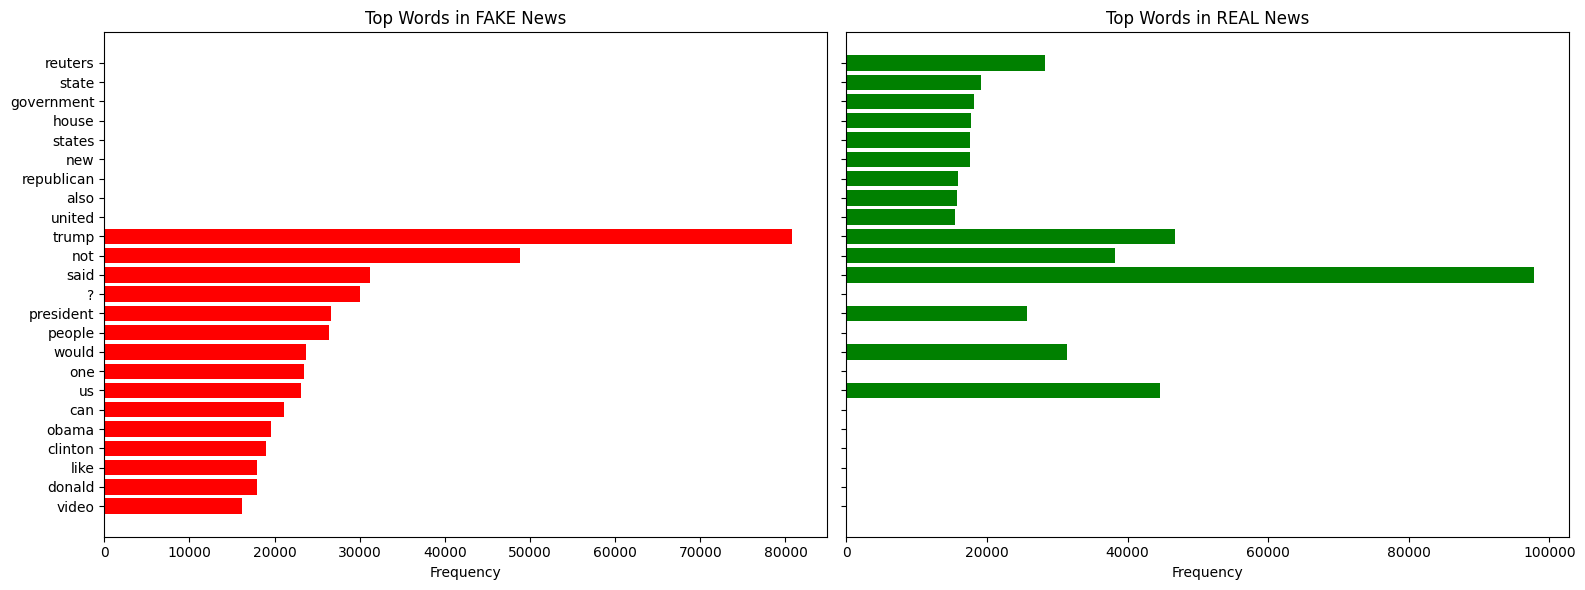

In [37]:
# Call the function to plot word frequencies
plot_word_frequencies(df_clean, top_n=15)

In [38]:
# Remove the word 'reuters' from the tokens
df_clean['tokens'] = df_clean['tokens'].apply(lambda tokens: [word for word in tokens if word != 'reuters'])

# Check the first 5 rows of the updated dataframe
df_clean.head(5)

,news,label,tokens
0,Donald Trump Sends Out Embarrassing New Year’s...,1,"[donald, trump, sends, embarrassing, new, year..."
1,Drunk Bragging Trump Staffer Started Russian C...,1,"[drunk, bragging, trump, staffer, started, rus..."
2,Sheriff David Clarke Becomes An Internet Joke ...,1,"[sheriff, david, clarke, becomes, internet, jo..."
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1,"[trump, obsessed, even, obamas, name, coded, w..."
4,Pope Francis Just Called Out Donald Trump Duri...,1,"[pope, francis, called, donald, trump, christm..."


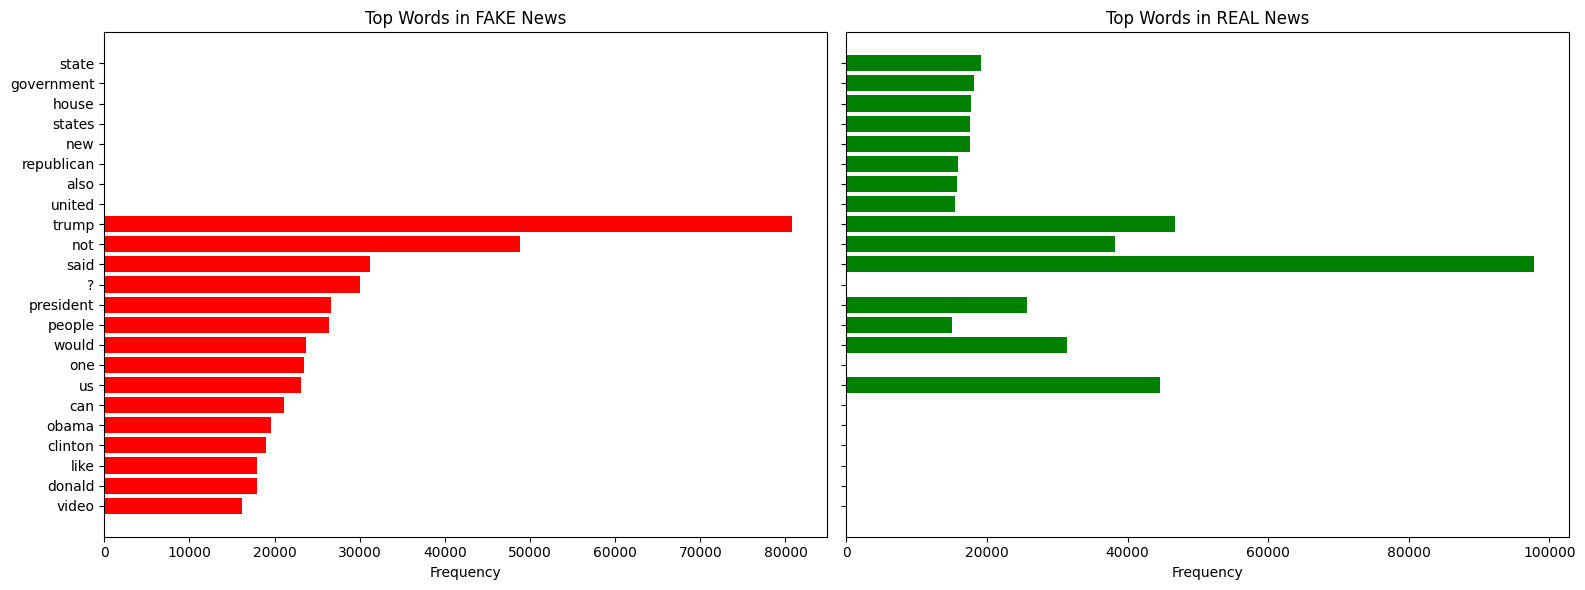

In [39]:
# Call the function to plot word frequencies
plot_word_frequencies(df_clean, top_n=15)

In [40]:
# rearrange the columns
df_clean = df_clean[['news', 'tokens', 'label']]
# check the first 5 rows of the new dataframe
df_clean.head(5)

,news,tokens,label
0,Donald Trump Sends Out Embarrassing New Year’s...,"[donald, trump, sends, embarrassing, new, year...",1
1,Drunk Bragging Trump Staffer Started Russian C...,"[drunk, bragging, trump, staffer, started, rus...",1
2,Sheriff David Clarke Becomes An Internet Joke ...,"[sheriff, david, clarke, becomes, internet, jo...",1
3,Trump Is So Obsessed He Even Has Obama’s Name ...,"[trump, obsessed, even, obamas, name, coded, w...",1
4,Pope Francis Just Called Out Donald Trump Duri...,"[pope, francis, called, donald, trump, christm...",1
